In [58]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'D2Coding' # 한글 문자 처리

In [83]:
sub_file = r"D:\Practice\hipython\data\CARD_SUBWAY_202102.csv"
sub_df = pd.read_csv(sub_file, usecols=range(0,6))  # 앞 6개의 컬럼만 사용

print(sub_df.columns)
# sub_df.tail()
# sub_df['사용일자']

sub_df['노선명'].unique()

sub_df = sub_df.drop(columns='등록일자')

sub_df

Index(['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '등록일자'], dtype='object')


,사용일자,노선명,역명,승차총승객수,하차총승객수
0,20210201,중앙선,용문,1282,1259
1,20210201,중앙선,지평,48,43
2,20210201,중앙선,아신,415,413
3,20210201,중앙선,양수,1463,1466
4,20210201,중앙선,운길산,495,463
...,...,...,...,...,...
16746,20210228,중앙선,오빈,216,236
16747,20210228,중앙선,양평,3299,3187
16748,20210228,중앙선,원덕,322,304
16749,20210228,중앙선,용문,1899,1716


In [84]:
# 사용일자 : 2021-02-01 형식으로 DateType
# df['컬럼명'] = df['컬럼명'].astype('새로운타입')

sub_df['사용일자'] = sub_df['사용일자'].astype(str)
sub_df['사용일자'] = [ "-".join([dt[0:4], dt[4:6], dt[6:]]) for dt in sub_df['사용일자'] ]

sub_df

,사용일자,노선명,역명,승차총승객수,하차총승객수
0,2021-02-01,중앙선,용문,1282,1259
1,2021-02-01,중앙선,지평,48,43
2,2021-02-01,중앙선,아신,415,413
3,2021-02-01,중앙선,양수,1463,1466
4,2021-02-01,중앙선,운길산,495,463
...,...,...,...,...,...
16746,2021-02-28,중앙선,오빈,216,236
16747,2021-02-28,중앙선,양평,3299,3187
16748,2021-02-28,중앙선,원덕,322,304
16749,2021-02-28,중앙선,용문,1899,1716


In [ ]:
sub_df.head()

In [ ]:
sub_df.value_counts('노선명')
sub_df['노선명'].value_counts()

In [ ]:
sub_line = sub_df.groupby('노선명')
# print(type(sub_line.size()), sub_line.size() )
df_line = pd.DataFrame(sub_line.size(), columns=['노선별건수'])
print('-'*50)
print(df_line)
sub_line[['승차총승객수', '하차총승객수']].sum(numeric_only=True).map("{:,}".format)

In [72]:
# 5호선 역별 데이터 카운트

sub_5_df = sub_df[sub_df['노선명']=='5호선']
top10_df_1 = sub_5_df.groupby('역명')[['승차총승객수', '하차총승객수']].sum().sort_values(by='승차총승객수', ascending=False).head(10)
top10_df_2 = sub_5_df.groupby('역명')[['승차총승객수', '하차총승객수']].sum().sort_values(by='하차총승객수', ascending=False).head(10)

top10_df = pd.concat([top10_df_1, top10_df_2]).drop_duplicates()
top10_df


,승차총승객수,하차총승객수
역명,,
까치산,639237,622602
광화문(세종문화회관),630350,640269
화곡,615789,580939
여의도,565332,576983
오목교(목동운동장앞),498904,533946
강동,417865,393081
천호(풍납토성),416520,409844
발산,405898,413888
장한평,386762,383986


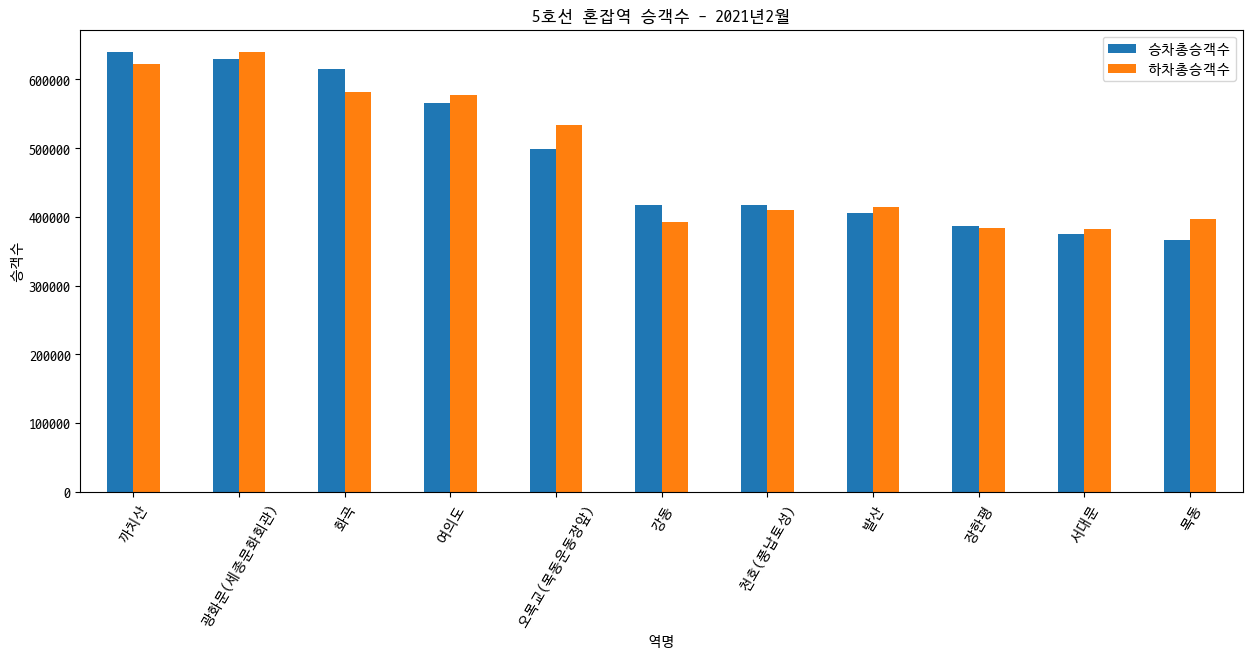

In [73]:
top10_df.plot(kind='bar', figsize=(15, 6))

# gr_sr.plot(kind='bar', color='skyblue', figsize=(10, 6))

plt.title('5호선 혼잡역 승객수 - 2021년2월')
plt.xlabel('역명')
plt.ylabel('승객수')
plt.xticks(rotation=60) # 글자가 겹치지 않게 회전
plt.show()

In [47]:
sub_line_station = sub_df.groupby(['노선명', '역명'])
sub_line_station['승차총승객수'].sum().sort_values(ascending=False).head(10)
sub_line_station['승차총승객수'].sum().sort_values(ascending=False).tail(10)

노선명  역명  
경의선  임진강     696
분당선  복정       16
6호선  연신내      15
3호선  충무로      15
경원선  창동       11
6호선  신내        6
경의선  계양        3
일산선  지축        2
경의선  검암        1
     김포공항      1
Name: 승차총승객수, dtype: int64

In [48]:
sub_line_station['하차총승객수'].sum().sort_values(ascending=False).head(10)
sub_line_station['하차총승객수'].sum().sort_values(ascending=False).tail(10)

노선명  역명  
경의선  임진강     468
6호선  신내        0
경의선  검암        0
경원선  창동        0
경의선  계양        0
     김포공항      0
3호선  충무로       0
분당선  복정        0
6호선  연신내       0
일산선  지축        0
Name: 하차총승객수, dtype: int64

In [112]:
# 승하자 승객수 차이 합 필드 추가 - 승하자승객수차이  승하차총승객수

sub_df['승하차승객수차이'] = sub_df['승차총승객수'] - sub_df['하차총승객수']
sub_df['승하차총승객수'] = sub_df['승차총승객수'] + sub_df['하차총승객수']

sub_df[sub_df['노선명']=='2호선'].sort_values(by='승차총승객수', ascending=False).head(20)

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하자승객수차이,승하차총승객수,승하차승객수차이
14984,2021-02-26,2호선,강남,88904,87891,1013,176795,1013
10857,2021-02-19,2호선,강남,86800,80948,5852,167748,5852
13705,2021-02-23,2호선,강남,84922,83364,1558,168286,1558
14314,2021-02-24,2호선,강남,84628,82667,1961,167295,1961
14384,2021-02-25,2호선,강남,84374,82960,1414,167334,1414
12585,2021-02-22,2호선,강남,83602,81970,1632,165572,1632
9266,2021-02-16,2호선,강남,83284,81590,1694,164874,1694
5310,2021-02-09,2호선,강남,83006,81087,1919,164093,1919
2989,2021-02-05,2호선,강남,82975,81476,1499,164451,1499
9638,2021-02-17,2호선,강남,82823,80269,2554,163092,2554


In [116]:
sub_2_top = sub_df[sub_df['노선명']=='2호선'].groupby('역명')[['승차총승객수', '하차총승객수', '승하차총승객수', '승하차승객수차이']].sum().sort_values(by='승하차총승객수',ascending=False).head(10)
sub_2_top

,승차총승객수,하차총승객수,승하차총승객수,승하차승객수차이
역명,,,,
강남,1830710,1782108,3612818,48602
잠실(송파구청),1493330,1466388,2959718,26942
신림,1404895,1371847,2776742,33048
구로디지털단지,1285603,1287537,2573140,-1934
홍대입구,1245353,1295601,2540954,-50248
신도림,1081836,1056358,2138194,25478
선릉,1106180,985250,2091430,120930
역삼,996247,1080097,2076344,-83850
서울대입구(관악구청),1047044,1028479,2075523,18565


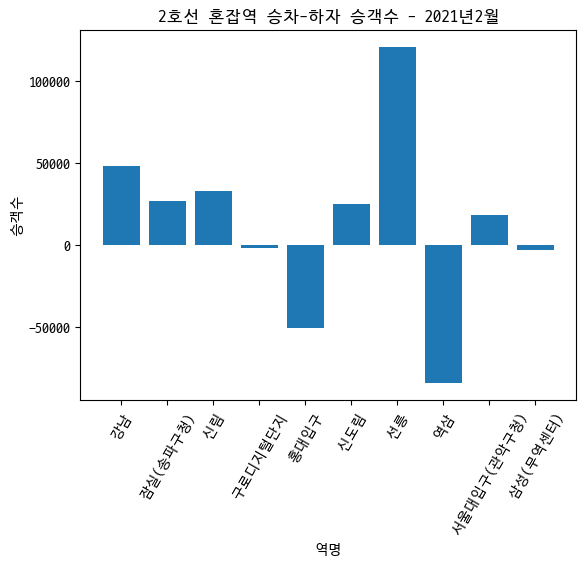

In [104]:
# sub_2_top.plot(kind='bar', figsize=(15, 6))

plt.bar(sub_2_top.index, sub_2_top['승하자승객수차이'])

# gr_sr.plot(kind='bar', color='skyblue', figsize=(10, 6))

plt.title('2호선 혼잡역 승차-하자 승객수 - 2021년2월')
plt.xlabel('역명')
plt.ylabel('승객수')
plt.xticks(rotation=60) # 글자가 겹치지 않게 회전
plt.show()

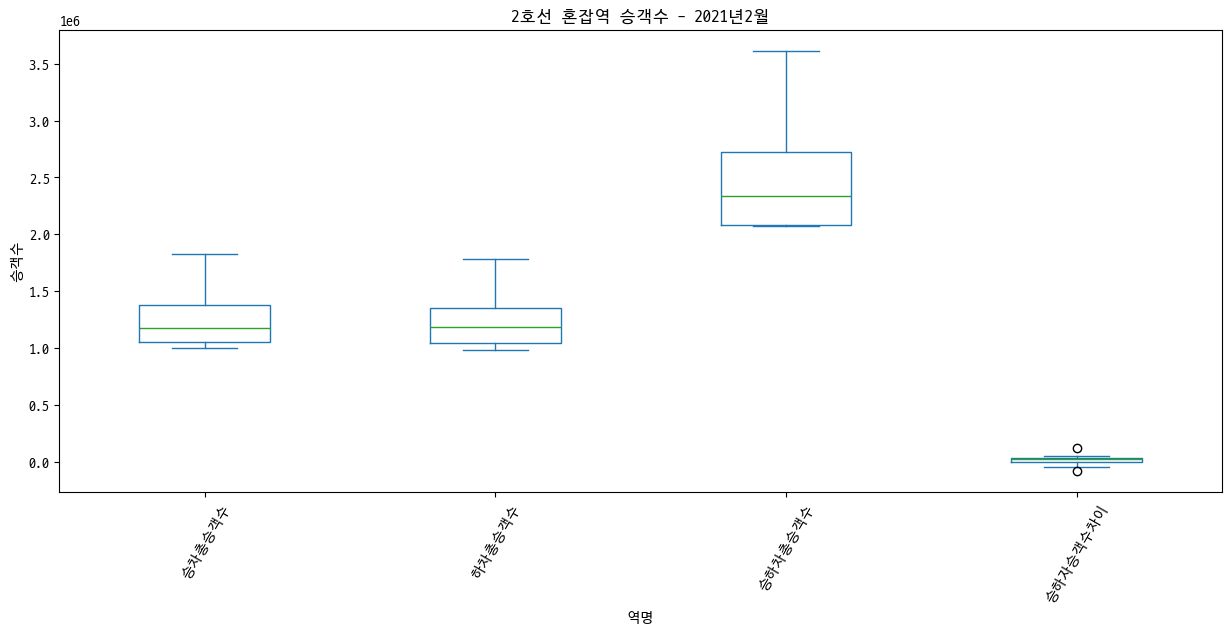

In [101]:
sub_2_top.plot(kind='box', figsize=(15, 6))

# plt.boxplot(sub_2_top['승하차총승객수'])
plt.title('2호선 혼잡역 승객수 - 2021년2월')
plt.xlabel('역명')
plt.ylabel('승객수')
plt.xticks(rotation=60) # 글자가 겹치지 않게 회전
plt.show()

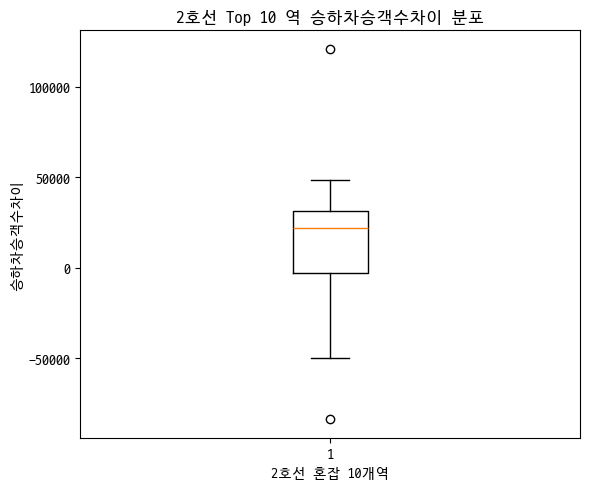

In [122]:
plt.figure(figsize=(6,5))
plt.boxplot(sub_2_top['승하차승객수차이'])
plt.title('2호선 Top 10 역 승하차승객수차이 분포')
plt.xlabel('2호선 혼잡 10개역')
plt.ylabel('승하차승객수차이')
plt.tight_layout()
plt.show()

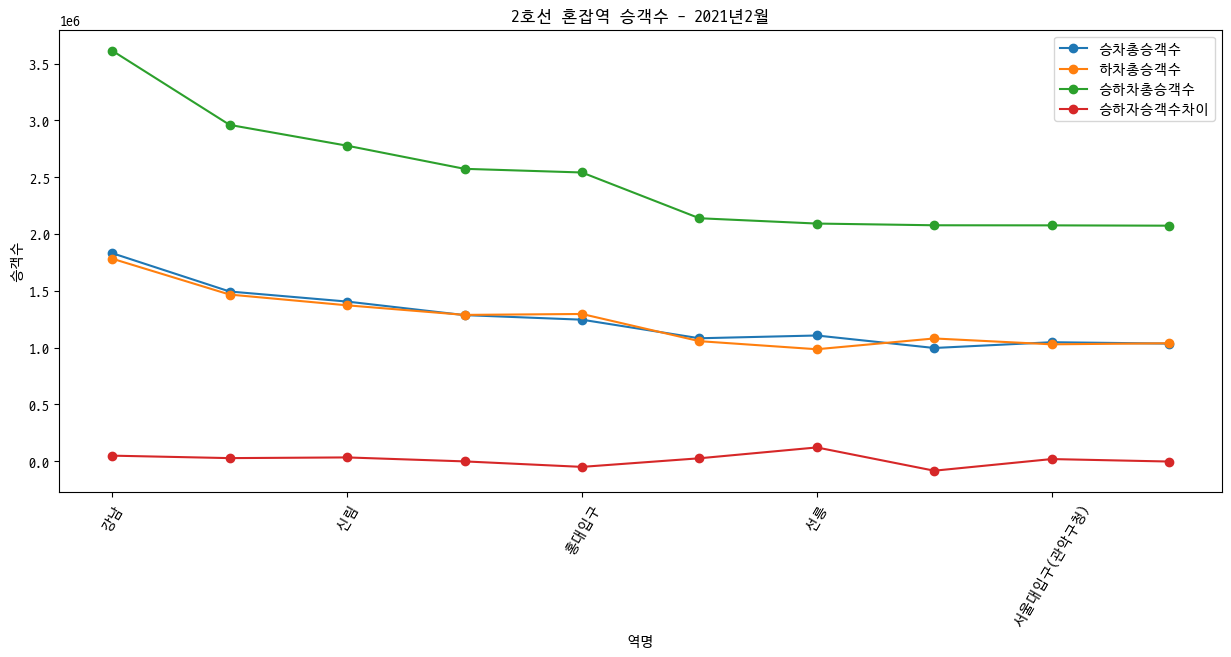

In [110]:
sub_2_top.plot(kind='line', figsize=(15, 6), marker='o')

# plt.boxplot(sub_2_top['승하차총승객수'])
plt.title('2호선 혼잡역 승객수 - 2021년2월')
plt.xlabel('역명')
plt.ylabel('승객수')
plt.xticks(rotation=60) # 글자가 겹치지 않게 회전
plt.show()

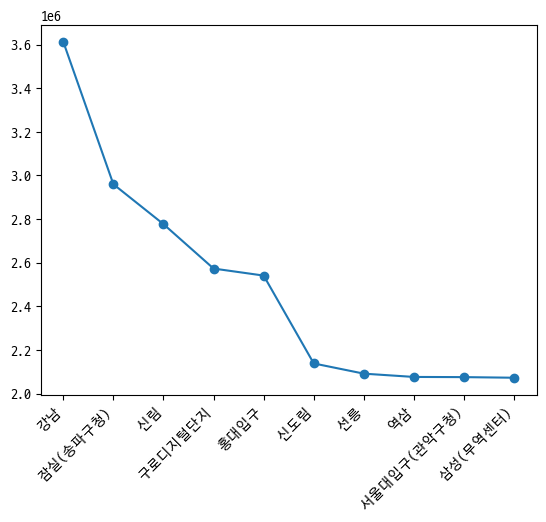

In [109]:
plt.plot(sub_2_top.index, sub_2_top['승하차총승객수'], marker='o') # sub_2_top.index : 역명
plt.xticks(rotation=45, ha='right')
plt.show()

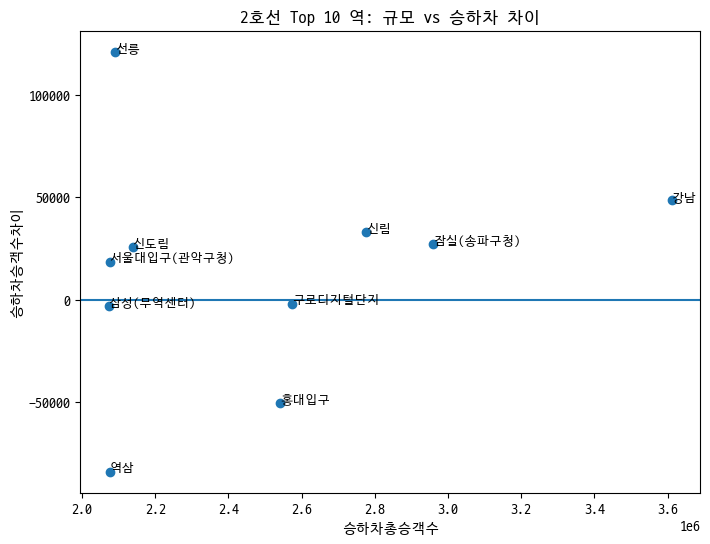

In [117]:
plt.figure(figsize=(8,6))
plt.scatter(
    sub_2_top['승하차총승객수'],
    sub_2_top['승하차승객수차이']
)
plt.axhline(0)  # 기준선
plt.title('2호선 Top 10 역: 규모 vs 승하차 차이')
plt.xlabel('승하차총승객수')
plt.ylabel('승하차승객수차이')


# 역명 라벨
for i in range(len(sub_2_top)):
    plt.text(
        sub_2_top['승하차총승객수'].iloc[i],
        sub_2_top['승하차승객수차이'].iloc[i],
        sub_2_top.index[i],
        fontsize=9
    )
plt.show()